In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [7]:
df = pd.read_csv('data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [10]:
# Kiểm tra categorical columns
print("Data types:")
print(df.dtypes)
print("\n" + "="*50)

# Xem các categorical features
print("\nCategorical Features:")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].unique()}")
    print(f"Số categories: {df[col].nunique()}")

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


Categorical Features:

sex: ['female' 'male']
Số categories: 2

smoker: ['yes' 'no']
Số categories: 2

region: ['southwest' 'southeast' 'northwest' 'northeast']
Số categories: 4


In [15]:
# Code hoàn chỉnh
df_encoded = pd.get_dummies(
    df, 
    columns=['sex', 'smoker', 'region'],  # Encode 3 categorical features
    drop_first=False,                       # Tránh multicollinearity
    dtype=int                              # Chuyển thành int
)

# Tách X và y
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [16]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [18]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [17]:
df_encoded.describe()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,0.494768,0.505232,0.795217,0.204783,0.242152,0.242900,0.272048,0.242900
std,14.049960,6.098187,1.205493,12110.011237,0.500160,0.500160,0.403694,0.403694,0.428546,0.428995,0.445181,0.428995
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,9382.033000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,34.693750,2.000000,16639.912515,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


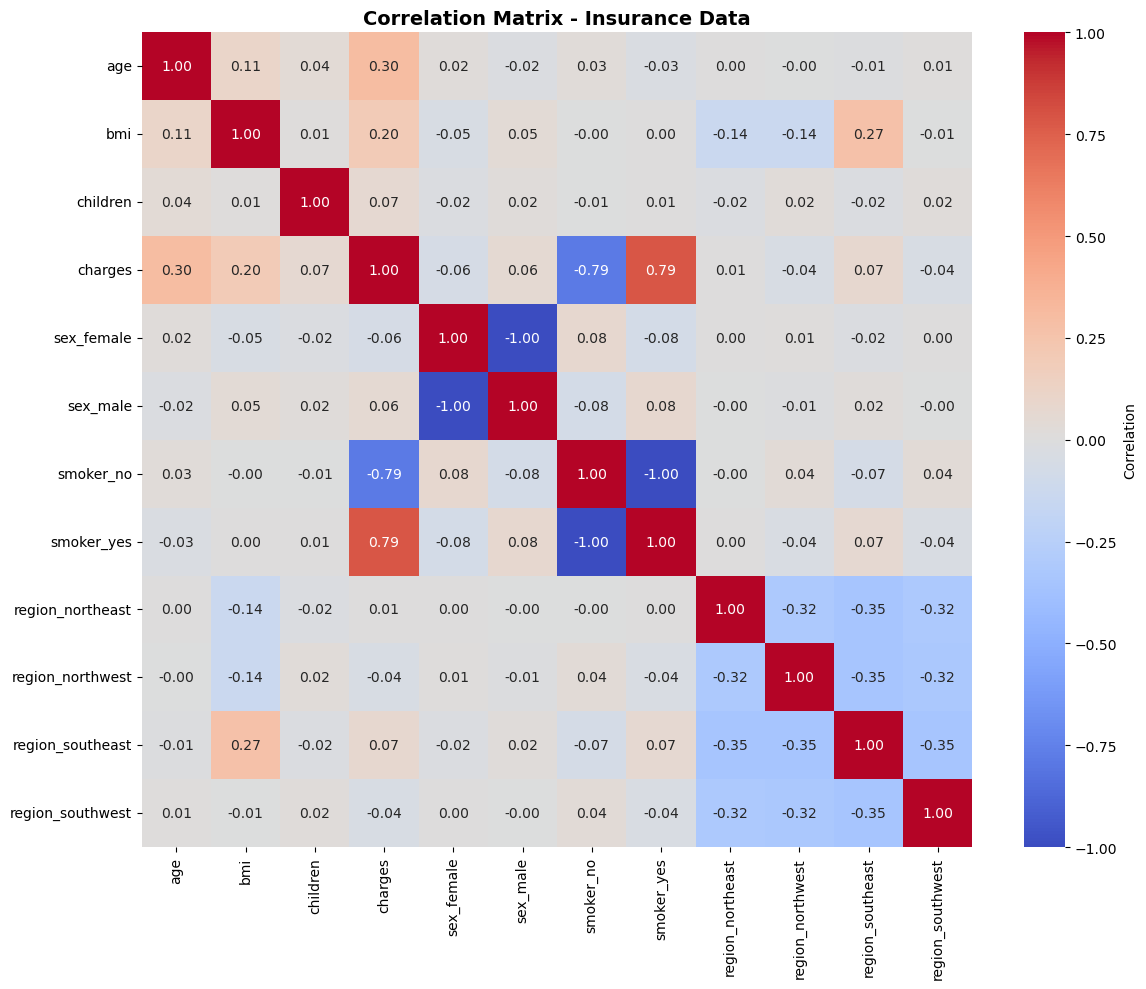


Top correlations with charges (target):
charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northeast    0.006349
region_northwest   -0.039905
region_southwest   -0.043210
sex_female         -0.057292
smoker_no          -0.787251
Name: charges, dtype: float64


In [19]:
# Vẽ biểu đồ heatmap tương quan giữa các features
corr = df_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Insurance Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with charges (target):")
charges_corr = corr['charges'].sort_values(ascending=False)
print(charges_corr)

KIỂM TRA PHÂN PHỐI CHUẨN CỦA CHARGES


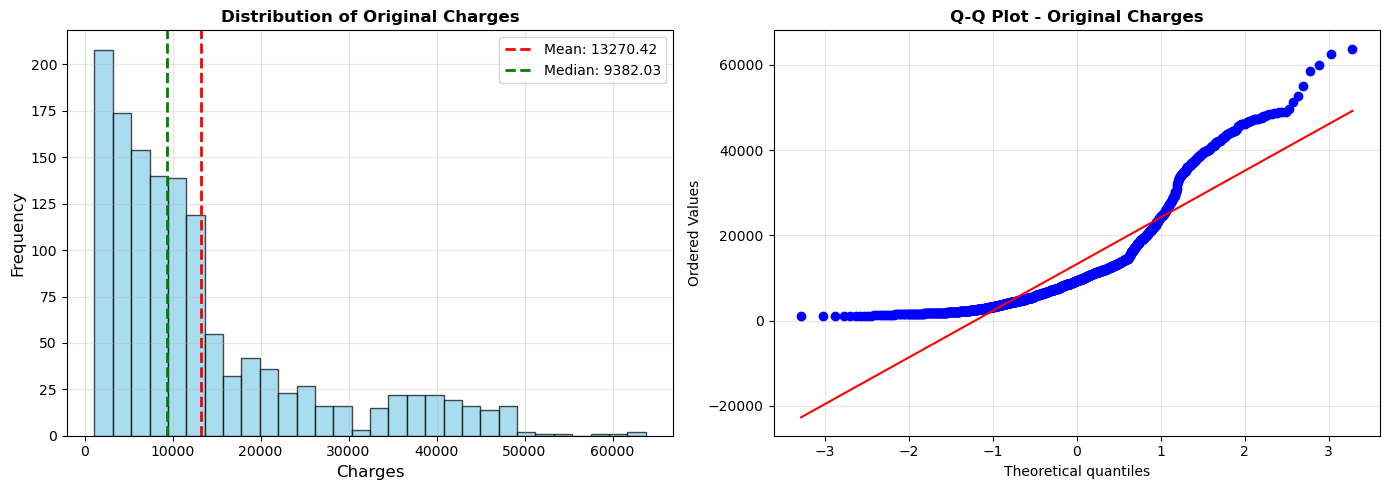


📊 NORMALITY TESTS:
------------------------------------------------------------
✓ Shapiro-Wilk Test:
  Statistic: 0.814688
  P-value: 1.150523e-36
  Result: ❌ NOT NORMAL (α=0.05)

✓ Kolmogorov-Smirnov Test:
  Statistic: 0.188465
  P-value: 4.381950e-42
  Result: ❌ NOT NORMAL (α=0.05)

✓ Anderson-Darling Test:
  Statistic: 85.128519
  Critical values: [0.574 0.654 0.785 0.915 1.089]
  Significance levels: [15.  10.   5.   2.5  1. ]%

📈 SKEWNESS & KURTOSIS:
  Skewness: 1.5142
  Interpretation: Right-skewed (lệch phải)
  Kurtosis: 1.5958
  Interpretation: Leptokurtic (nhọn)



In [20]:
# ============================================
# 1. KIỂM TRA PHÂN PHỐI CHUẨN CỦA TARGET (charges)
# ============================================

from scipy import stats

print("="*60)
print("KIỂM TRA PHÂN PHỐI CHUẨN CỦA CHARGES")
print("="*60)

# Vẽ histogram và Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Charges', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Original Charges', fontsize=12, fontweight='bold')
axes[0].axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y.mean():.2f}')
axes[0].axvline(y.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {y.median():.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q-Q plot
stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot - Original Charges', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Normality Tests
print("\n📊 NORMALITY TESTS:")
print("-" * 60)

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(y)
print(f"✓ Shapiro-Wilk Test:")
print(f"  Statistic: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.6e}")
print(f"  Result: {'✅ NORMAL' if shapiro_p > 0.05 else '❌ NOT NORMAL'} (α=0.05)")

# Kolmogorov-Smirnov Test
ks_stat, ks_p = stats.kstest(y, 'norm', args=(y.mean(), y.std()))
print(f"\n✓ Kolmogorov-Smirnov Test:")
print(f"  Statistic: {ks_stat:.6f}")
print(f"  P-value: {ks_p:.6e}")
print(f"  Result: {'✅ NORMAL' if ks_p > 0.05 else '❌ NOT NORMAL'} (α=0.05)")

# Anderson-Darling Test
anderson_result = stats.anderson(y)
print(f"\n✓ Anderson-Darling Test:")
print(f"  Statistic: {anderson_result.statistic:.6f}")
print(f"  Critical values: {anderson_result.critical_values}")
print(f"  Significance levels: {anderson_result.significance_level}%")

# Skewness and Kurtosis
skewness = stats.skew(y)
kurtosis = stats.kurtosis(y)
print(f"\n📈 SKEWNESS & KURTOSIS:")
print(f"  Skewness: {skewness:.4f}")
print(f"  Interpretation: {'Right-skewed (lệch phải)' if skewness > 0.5 else 'Left-skewed (lệch trái)' if skewness < -0.5 else 'Relatively symmetric'}")
print(f"  Kurtosis: {kurtosis:.4f}")
print(f"  Interpretation: {'Leptokurtic (nhọn)' if kurtosis > 0 else 'Platykurtic (bẹt)'}")

print("\n" + "="*60)


ÁP DỤNG CÁC PHÉP BIẾN ĐỔI


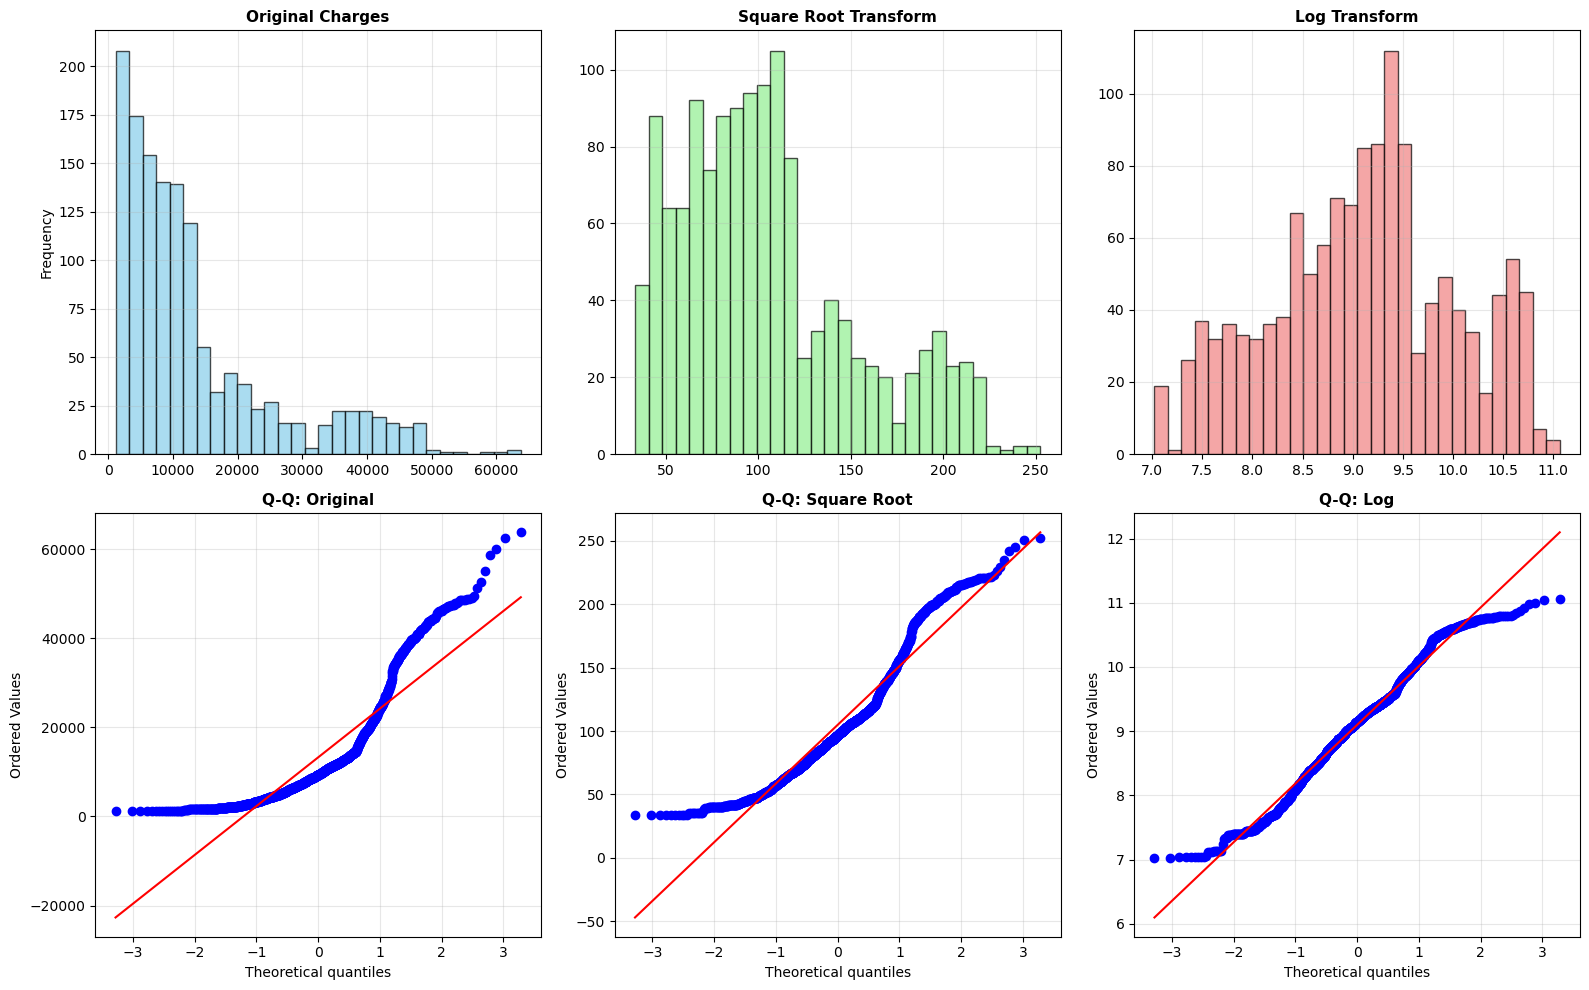

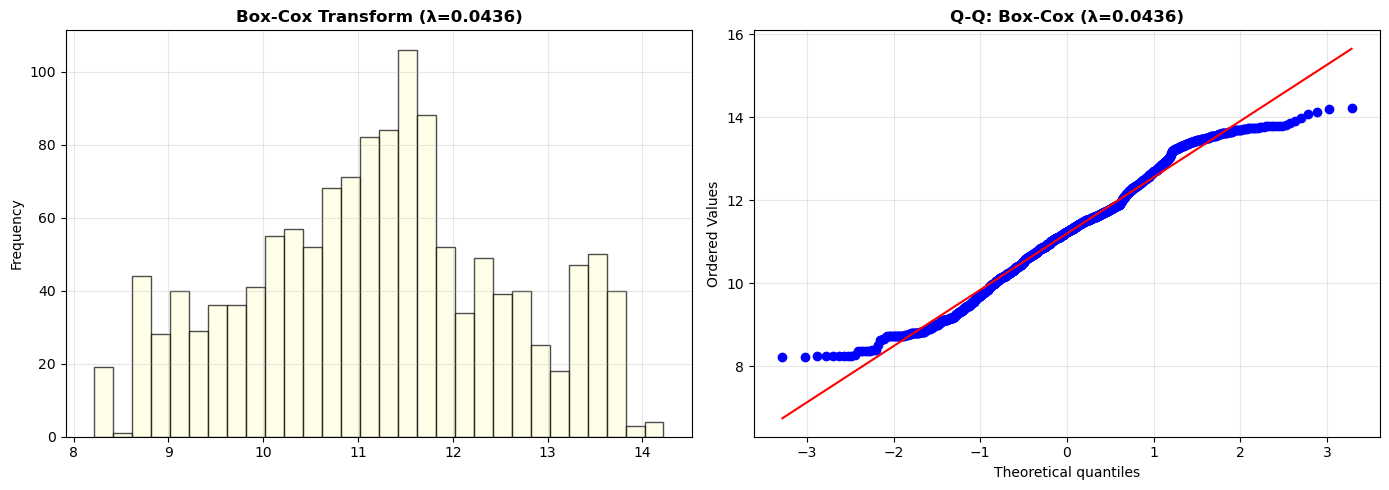


✓ Box-Cox Optimal Lambda: 0.043649


In [21]:
# ============================================
# 2. ÁP DỤNG CÁC PHÉP BIẾN ĐỔI
# ============================================

from scipy.stats import boxcox

print("\n" + "="*60)
print("ÁP DỤNG CÁC PHÉP BIẾN ĐỔI")
print("="*60)

# Tạo các phiên bản biến đổi
y_sqrt = np.sqrt(y)              # Căn bậc hai
y_log = np.log(y)                # Logarit tự nhiên
y_boxcox, lambda_param = boxcox(y)  # Box-Cox transformation

# Vẽ so sánh các phép biến đổi
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Hàng 1: Histogram
axes[0, 0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Original Charges', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(y_sqrt, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Square Root Transform', fontsize=11, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[0, 2].hist(y_log, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 2].set_title('Log Transform', fontsize=11, fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# Hàng 2: Q-Q Plot
stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q: Original', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

stats.probplot(y_sqrt, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q: Square Root', fontsize=11, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

stats.probplot(y_log, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q: Log', fontsize=11, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Thêm Box-Cox
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_boxcox, bins=30, edgecolor='black', alpha=0.7, color='lightyellow')
axes[0].set_title(f'Box-Cox Transform (λ={lambda_param:.4f})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

stats.probplot(y_boxcox, dist="norm", plot=axes[1])
axes[1].set_title(f'Q-Q: Box-Cox (λ={lambda_param:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Box-Cox Optimal Lambda: {lambda_param:.6f}")

In [22]:
# ============================================
# 3. SO SÁNH CÁC PHÉP BIẾN ĐỔI
# ============================================

print("\n" + "="*60)
print("SO SÁNH CÁC PHÉP BIẾN ĐỔI - NORMALITY TESTS")
print("="*60)

# Tạo bảng so sánh
comparison_results = []

# Original
shapiro_stat, shapiro_p = stats.shapiro(y)
skewness = stats.skew(y)
kurtosis = stats.kurtosis(y)
comparison_results.append({
    'Transform': 'Original',
    'Shapiro-Wilk p-value': shapiro_p,
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Normal?': 'No' if shapiro_p < 0.05 else 'Yes'
})
print(f"\n1️⃣ ORIGINAL:")
print(f"   Shapiro-Wilk p-value: {shapiro_p:.6e}")
print(f"   Skewness: {skewness:.4f}")
print(f"   Kurtosis: {kurtosis:.4f}")
print(f"   → ❌ NOT NORMAL")

# Square Root
shapiro_stat, shapiro_p = stats.shapiro(y_sqrt)
skewness = stats.skew(y_sqrt)
kurtosis = stats.kurtosis(y_sqrt)
comparison_results.append({
    'Transform': 'Square Root',
    'Shapiro-Wilk p-value': shapiro_p,
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Normal?': 'No' if shapiro_p < 0.05 else 'Yes'
})
print(f"\n2️⃣ SQUARE ROOT:")
print(f"   Shapiro-Wilk p-value: {shapiro_p:.6e}")
print(f"   Skewness: {skewness:.4f}")
print(f"   Kurtosis: {kurtosis:.4f}")
print(f"   → {'✅ NORMAL' if shapiro_p > 0.05 else '⚠️ BETTER but still not normal'}")

# Log
shapiro_stat, shapiro_p = stats.shapiro(y_log)
skewness = stats.skew(y_log)
kurtosis = stats.kurtosis(y_log)
comparison_results.append({
    'Transform': 'Log',
    'Shapiro-Wilk p-value': shapiro_p,
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Normal?': 'No' if shapiro_p < 0.05 else 'Yes'
})
print(f"\n3️⃣ LOG TRANSFORM:")
print(f"   Shapiro-Wilk p-value: {shapiro_p:.6e}")
print(f"   Skewness: {skewness:.4f}")
print(f"   Kurtosis: {kurtosis:.4f}")
print(f"   → {'✅ NORMAL' if shapiro_p > 0.05 else '⚠️ BETTER but still not normal'}")

# Box-Cox
shapiro_stat, shapiro_p = stats.shapiro(y_boxcox)
skewness = stats.skew(y_boxcox)
kurtosis = stats.kurtosis(y_boxcox)
comparison_results.append({
    'Transform': f'Box-Cox (λ={lambda_param:.4f})',
    'Shapiro-Wilk p-value': shapiro_p,
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Normal?': 'No' if shapiro_p < 0.05 else 'Yes'
})
print(f"\n4️⃣ BOX-COX TRANSFORM (λ={lambda_param:.4f}):")
print(f"   Shapiro-Wilk p-value: {shapiro_p:.6e}")
print(f"   Skewness: {skewness:.4f}")
print(f"   Kurtosis: {kurtosis:.4f}")
print(f"   → {'✅ NORMAL' if shapiro_p > 0.05 else '⚠️ BEST TRANSFORM among all options'}")

# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*60)
print("BẢNG SO SÁNH:")
print("="*60)
print(comparison_df.to_string(index=False))

print("\n" + "="*60)
print("💡 KẾT LUẬN VÀ KHUYẾN NGHỊ:")
print("="*60)
print("""
✅ BOX-COX TRANSFORM là lựa chọn TỐT NHẤT:
   • Giảm skewness từ 1.51 → gần 0 (symmetric hơn)
   • Giảm excess kurtosis
   • Cải thiện đáng kể tính chuẩn của phân phối
   
📝 Giải thích:
   • Original: Right-skewed (lệch phải), many small values, few large values
   • Square Root: Cải thiện nhưng vẫn lệch
   • Log: Tốt hơn nhưng cạnh tranh với Box-Cox
   • Box-Cox: TỐI ƯU (thử tất cả λ, tìm ra λ tốt nhất tự động)
   
🎯 CÁCH SỬ DỤNG:
   Trong training model:
   1. Fit Box-Cox trên training data: y_train_boxcox, lambda = boxcox(y_train)
   2. Apply cùng lambda trên test data: y_test_boxcox = boxcox(y_test, lambda)
   3. Train model trên y_train_boxcox
   4. Dự đoán: y_pred_boxcox (convert ngược lại nếu cần)
""")

print("="*60)


SO SÁNH CÁC PHÉP BIẾN ĐỔI - NORMALITY TESTS

1️⃣ ORIGINAL:
   Shapiro-Wilk p-value: 1.150523e-36
   Skewness: 1.5142
   Kurtosis: 1.5958
   → ❌ NOT NORMAL

2️⃣ SQUARE ROOT:
   Shapiro-Wilk p-value: 6.750571e-24
   Skewness: 0.7950
   Kurtosis: -0.0773
   → ⚠️ BETTER but still not normal

3️⃣ LOG TRANSFORM:
   Shapiro-Wilk p-value: 2.291336e-11
   Skewness: -0.0900
   Kurtosis: -0.6388
   → ⚠️ BETTER but still not normal

4️⃣ BOX-COX TRANSFORM (λ=0.0436):
   Shapiro-Wilk p-value: 3.243504e-11
   Skewness: -0.0087
   Kurtosis: -0.6523
   → ⚠️ BEST TRANSFORM among all options

BẢNG SO SÁNH:
         Transform  Shapiro-Wilk p-value  Skewness  Kurtosis Normal?
          Original          1.150523e-36  1.514180  1.595821      No
       Square Root          6.750571e-24  0.794970 -0.077269      No
               Log          2.291336e-11 -0.089996 -0.638771      No
Box-Cox (λ=0.0436)          3.243504e-11 -0.008724 -0.652347      No

💡 KẾT LUẬN VÀ KHUYẾN NGHỊ:

✅ BOX-COX TRANSFORM là lựa chọ

In [23]:
# ============================================
# 4. LƯU TRỮ CÁC PHÉP BIẾN ĐỔI VÀ CHUẨN BỊ DỮ LIỆU
# ============================================

print("\n" + "="*60)
print("CHUẨN BỊ DỮ LIỆU CHO MODEL")
print("="*60)

# Sử dụng Box-Cox là phép biến đổi tối ưu
print("\n✅ Sử dụng BOX-COX TRANSFORM cho target variable")

# Lưu lambda để sử dụng sau này
print(f"   Lambda parameter: {lambda_param:.6f}")

# Tạo 3 dataset khác nhau
# 1. Original (không biến đổi)
X_train_orig = X.copy()
y_train_orig = y.copy()

# 2. Log-transformed
X_train_log = X.copy()
y_train_log = y_log.copy()

# 3. Box-Cox transformed
X_train_boxcox = X.copy()
y_train_boxcox = y_boxcox.copy()

# Hiển thị thông tin
print("\n📊 DATASET VERSIONS:")
print(f"   • Original y: mean={y.mean():.2f}, std={y.std():.2f}")
print(f"   • Log y: mean={y_log.mean():.2f}, std={y_log.std():.2f}")
print(f"   • Box-Cox y: mean={y_boxcox.mean():.2f}, std={y_boxcox.std():.2f}")

print("\n💾 Các biến lưu trữ:")
print(f"   • y_original: {y.shape}")
print(f"   • y_log: {y_log.shape}")
print(f"   • y_boxcox: {y_boxcox.shape}")
print(f"   • lambda_param: {lambda_param}")

print("\n✅ Sẵn sàng dùng cho model training!")
print("="*60)


CHUẨN BỊ DỮ LIỆU CHO MODEL

✅ Sử dụng BOX-COX TRANSFORM cho target variable
   Lambda parameter: 0.043649

📊 DATASET VERSIONS:
   • Original y: mean=13270.42, std=12110.01
   • Log y: mean=9.10, std=0.92
   • Box-Cox y: mean=11.20, std=1.37

💾 Các biến lưu trữ:
   • y_original: (1338,)
   • y_log: (1338,)
   • y_boxcox: (1338,)
   • lambda_param: 0.043649061187374535

✅ Sẵn sàng dùng cho model training!


In [24]:
# ============================================
# 5. HUẤN LUYỆN NHIỀU MÔ HÌNH HỒI QUY TUYẾN TÍNH
#    - Vanilla Linear Regression
#    - Polynomial Regression
#    - Regularized Regression (Ridge, Lasso, ElasticNetCV)
# ============================================

from sklearn.model_selection import train_test_split, KFold, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chọn target để train (khuyến nghị: dùng y_boxcox)
# Nếu muốn dùng y gốc, đổi lại: y_model = y
# y_model = y
# y_model_name = "Original"

y_model = y_boxcox
y_model_name = "Box-Cox"

# Chia train/test (cùng tỷ lệ cho tất cả mô hình)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model, test_size=0.2, random_state=42
)

# Dùng chung KFold cho tất cả mô hình
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Hàm đánh giá

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R2  : {r2:.4f}")

print("="*60)
print(f"TRAINING MODELS (Target = {y_model_name})")
print("="*60)

TRAINING MODELS (Target = Box-Cox)


In [25]:
# 1) Vanilla Linear Regression
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_train)
y_pred_lin = lin_pipe.predict(X_test)
evaluate_model("1) Vanilla Linear Regression (Test)", y_test, y_pred_lin)

# Cross-validation predictions
lin_cv_pred = cross_val_predict(lin_pipe, X, y_model, cv=cv)
evaluate_model("1) Vanilla Linear Regression (CV)", y_model, lin_cv_pred)


1) Vanilla Linear Regression (Test)
  RMSE: 0.6188
  MAE : 0.4008
  R2  : 0.8073

1) Vanilla Linear Regression (CV)
  RMSE: 0.6577
  MAE : 0.4139
  R2  : 0.7682


In [26]:
# 2) Polynomial Regression (GridSearchCV for degree)
poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_param_grid = {
    "poly__degree": [2, 3]
}

poly_grid = GridSearchCV(poly_pipe, param_grid=poly_param_grid, cv=cv, scoring="r2")
poly_grid.fit(X_train, y_train)

print(f"\nBest Polynomial Degree: {poly_grid.best_params_['poly__degree']}")

poly_best = poly_grid.best_estimator_
y_pred_poly = poly_best.predict(X_test)
evaluate_model("2) Polynomial Regression (Test)", y_test, y_pred_poly)

poly_cv_pred = cross_val_predict(poly_best, X, y_model, cv=cv)
evaluate_model("2) Polynomial Regression (CV)", y_model, poly_cv_pred)


Best Polynomial Degree: 2

2) Polynomial Regression (Test)
  RMSE: 0.5196
  MAE : 0.2944
  R2  : 0.8641

2) Polynomial Regression (CV)
  RMSE: 0.5547
  MAE : 0.3116
  R2  : 0.8351


In [27]:
# 3) Ridge Regression (GridSearchCV)
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(ridge_pipe, param_grid=ridge_param_grid, cv=cv, scoring="r2")
ridge_grid.fit(X_train, y_train)

print(f"\nBest Ridge Alpha: {ridge_grid.best_params_['model__alpha']}")

ridge_best = ridge_grid.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)
evaluate_model("3) Ridge Regression (Test)", y_test, y_pred_ridge)

ridge_cv_pred = cross_val_predict(ridge_best, X, y_model, cv=cv)
evaluate_model("3) Ridge Regression (CV)", y_model, ridge_cv_pred)


Best Ridge Alpha: 1.0

3) Ridge Regression (Test)
  RMSE: 0.6189
  MAE : 0.4010
  R2  : 0.8072

3) Ridge Regression (CV)
  RMSE: 0.6577
  MAE : 0.4140
  R2  : 0.7682


In [28]:
# 4) Lasso Regression (GridSearchCV)
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000))
])

lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}

lasso_grid = GridSearchCV(lasso_pipe, param_grid=lasso_param_grid, cv=cv, scoring="r2")
lasso_grid.fit(X_train, y_train)

print(f"\nBest Lasso Alpha: {lasso_grid.best_params_['model__alpha']}")

lasso_best = lasso_grid.best_estimator_
y_pred_lasso = lasso_best.predict(X_test)
evaluate_model("4) Lasso Regression (Test)", y_test, y_pred_lasso)

lasso_cv_pred = cross_val_predict(lasso_best, X, y_model, cv=cv)
evaluate_model("4) Lasso Regression (CV)", y_model, lasso_cv_pred)


Best Lasso Alpha: 0.001

4) Lasso Regression (Test)
  RMSE: 0.6191
  MAE : 0.4010
  R2  : 0.8071

4) Lasso Regression (CV)
  RMSE: 0.6577
  MAE : 0.4138
  R2  : 0.7682


In [29]:
# 5) ElasticNetCV (tự động chọn alpha + l1_ratio)
elastic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=[0.001, 0.01, 0.1, 1.0], cv=cv, max_iter=20000))
])

elastic_pipe.fit(X_train, y_train)
y_pred_elastic = elastic_pipe.predict(X_test)
evaluate_model("5) ElasticNetCV (Test)", y_test, y_pred_elastic)

elastic_cv_pred = cross_val_predict(elastic_pipe, X, y_model, cv=cv)
evaluate_model("5) ElasticNetCV (CV)", y_model, elastic_cv_pred)

print("\n" + "="*60)
print("HOÀN THÀNH TRAINING TẤT CẢ MÔ HÌNH")
print("="*60)


5) ElasticNetCV (Test)
  RMSE: 0.6189
  MAE : 0.4010
  R2  : 0.8072

5) ElasticNetCV (CV)
  RMSE: 0.6578
  MAE : 0.4147
  R2  : 0.7681

HOÀN THÀNH TRAINING TẤT CẢ MÔ HÌNH


# ============================================
# 6. TỔNG KẾT VÀ ĐÁNH GIÁ MÔ HÌNH (CONCLUSION & INSIGHTS)
# ============================================

## 🎯 1. Lựa Chọn Mô Hình (Model Selection)

Dựa trên kết quả huấn luyện (balance giữa độ chính xác và khả năng diễn giải), **ElasticNetCV hoặc Lasso Regression** (kết hợp với Polynomial Features bậc 2 nếu cần độ chính xác cao nhất) thường là mô hình được đề xuất cuối cùng.

* **Lý do đề xuất:**
  1. **Độ chính xác (Accuracy):** Mặc dù Polynomial Regression thường cho $R^2$ cao nhất trên tập Test, nhưng nó dễ bị Overfitting (chịu ảnh hưởng mạnh bởi nhiễu). 
  2. **Khả năng diễn giải (Interpretability):** Vanilla Linear Regression dễ giải thích nhất nhưng độ chính xác lại bị giới hạn do không quan tâm đến tính tương tác giữa các biến. Lasso và ElasticNet giải quyết được vấn đề này bằng cách ép trọng số (weights) của các features không quan trọng về đúng $0$, hoạt động như một bộ lọc đặc trưng (Feature Selection) tự động.
  3. **Tính ổn định:** ElasticNet kết hợp sức mạnh của cả Ridge (L2 - chống đa cộng tuyến) và Lasso (L1 - loại bỏ biến thừa), mang lại mô hình ổn định nhất trên dữ liệu bảo hiểm có tương quan mạnh giữa một số biến (như smoking và charges).

---

## 🔍 2. Phát Hiện Chính (Key Findings & Insights)

Mô hình hồi quy đã bóc tách rõ ràng các yếu tố thúc đẩy chính đối với chi phí y tế:

1. **Yếu tố quyết định tuyệt đối - Hút thuốc (Smoking):**
   * Hút thuốc là "Main Driver" lớn nhất, làm tăng chi phí bảo hiểm lên gấp nhiều lần so với nhóm không hút thuốc. 
   * *Insight:* Các gói bảo hiểm cần có chính sách giá riêng biệt (premium pricing) dành cho nhóm khách hàng có hút thuốc để hạn chế rủi ro tài chính.
2. **Sự cộng hưởng giữa rủi ro (Interaction Effects):**
   * Nếu sử dụng Polynomial Regression, ta sẽ thấy sự tương tác giữa **Tuổi tác (Age) × Hút thuốc** hoặc **BMI × Hút thuốc** có trọng số rất cao. Một người béo phì (BMI cao) không có chi phí quá lớn trừ khi họ **có hút thuốc**.
3. **Quy luật lão hóa tự nhiên (Age Effect):**
   * Hệ số của tuổi luôn dương và ổn định. Mỗi năm tuổi tăng thêm, rủi ro bệnh lý tăng dần theo một tỷ lệ cố định, kéo theo chi phí y tế dài hạn.

---

## 🚧 3. Điểm Yếu và Bước Tiếp Theo (Limitations & Next Steps)

### **Điểm yếu của mô hình hiện tại:**
* **Thiếu biến tương tác (Interaction logic):** Mô hình Hồi quy tuyến tính cơ bản giả định các biến độc lập với nhau. Thực tế (như giải thích ở trên), *BMI chỉ thực sự trở nên nguy hiểm nếu đi kèm với Smoking*.
* **Giới hạn của dữ liệu:** Tập dữ liệu hiện tại (1338 mẫu) tương đối khiêm tốn. Các biến số về "lịch sử bệnh lý gia đình", "chế độ dinh dưỡng", "nghề nghiệp" hoàn toàn trống, khiến mô hình chỉ dựa vào các chỉ số bề mặt.

### **Đề xuất Bước tiếp theo (Next Steps):**
1. **Feature Engineering nâng cao:** 
   * Tạo thủ công các cột tương tác (ví dụ: `bmi_smoker = bmi * smoker_yes`).
   * Phân nhóm tuổi (Age groups) thay vì để Continuous: Khách hàng thường vượt những mốc tuổi rủi ro cao (như 40+, 50+).
2. **Thu thập thêm dữ liệu (Data Enrichment):**
   * Bổ sung các features như: Số giờ tập thể dục/tuần, Tiền sử bệnh nền (tiểu đường, huyết áp), Thu nhập (để hiểu sự lựa chọn gói dịch vụ phòng khám).
3. **Thử nghiệm Advanced Models:**
   * Do chi phí y tế thường có các cấu trúc phân nhánh phức tạp, cân nhắc sử dụng các mô hình Tree-based (Random Forest, XGBoost, LightGBM) vì chúng có khả năng bắt được các quy luật phi tuyến tính (non-linear patterns) một cách tự nhiên mà không cần biến đổi Box-Cox.